In [1]:
def show_avg_dice(results, extract_lens=False):
    prompt_dices, nn_dices = [], []
    prompt_win_dices, nn_win_dices = [], []
    interactions, lengths = [], []

    for volume_key, volume_data in results.items():
        for run_key, run_data in volume_data.items():
            # Extract Dices
            prompt_dice, prompt_win_dice = run_data["Prompt U-Net"]["Dices"]
            nn_dice, nn_win_dice = run_data["nnInteractive"]["Dices"]
            prompt_dices.append(prompt_dice)
            nn_dices.append(nn_dice)
            prompt_win_dices.append(prompt_win_dice)
            nn_win_dices.append(nn_win_dice)

            # Extract User Interactions & lengths
            interactions.append(run_data["Prompt U-Net"]["User Interactions"])
            if extract_lens:
                lengths.append(run_data["Prompt U-Net"]["Len Cropped Volume"])

    # Compute averages
    avg_prompt_dice = sum(prompt_dices) / len(prompt_dices)
    avg_nn_dice = sum(nn_dices) / len(nn_dices)
    avg_prompt_win_dice = sum(prompt_win_dices) / len(prompt_win_dices)
    avg_nn_win_dice = sum(nn_win_dices) / len(nn_win_dices)
    avg_interactions = sum(interactions) / len(interactions)
    if extract_lens:
        avg_len = sum(lengths) / len(lengths)
    
    # Print results
    print("Average Prompt U-Net Dice:", avg_prompt_dice)
    print("Average nnInteractive Dice:", avg_nn_dice)
    print("Average Prompt U-Net Window Dice:", avg_prompt_win_dice)
    print("Average nnInteractive Window Dice:", avg_nn_win_dice)
    print("Average Interactions:", avg_interactions)
    if extract_lens:
        print("Average Cropped Volume Length:", avg_len)

In [2]:
import matplotlib.pyplot as plt

def plot_dice_boxplots_from_results(results, model_labels=("Prompt U-Net", "nnInteractive")):
    """
    Extracts Dice scores from a nested results dictionary and plots a compact boxplot comparison.

    Parameters:
    - results (dict): Nested dictionary containing Dice scores for both models.
    - model_labels (tuple of str): Labels for the two models (default: ("Prompt U-Net", "nnInteractive"))
    """

    prompt_dices = []
    nn_dices = []

    # Extract dice values
    for volume_key, volume_data in results.items():
        for run_key, run_data in volume_data.items():
            prompt_dice, _ = run_data["Prompt U-Net"]["Dices"]
            nn_dice, _ = run_data["nnInteractive"]["Dices"]
            prompt_dices.append(prompt_dice)
            nn_dices.append(nn_dice)

    # Plot boxplot
    plt.figure(figsize=(3.2, 3.8))
    plt.boxplot(
        [prompt_dices, nn_dices],
        labels=model_labels,
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor='lightgray', color='black'),
        medianprops=dict(color='red', linewidth=1.5),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
    )

    # Optional compact settings
    # plt.ylim(0.5, 1.0)
    # plt.yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    plt.tight_layout()
    plt.show()


In [3]:
import pickle

96 tests per pkl

# With interacts

Average Prompt U-Net Dice: 0.8578058423397353
Average nnInteractive Dice: 0.787533239344557
Average Prompt U-Net Window Dice: 0.8923671152442694
Average nnInteractive Window Dice: 0.7843658978429934
Average Interactions: 12.15625


/tmp/ipykernel_3107260/2103034352.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


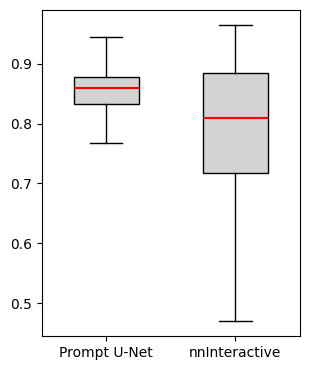

In [6]:
with open("results_3d_body_with_interactions_21_combined.pkl", "rb") as f:
    loaded_results = pickle.load(f)
show_avg_dice(loaded_results)
plot_dice_boxplots_from_results(loaded_results)

# No interacts

Average Prompt U-Net Dice: 0.5504563438045684
Average nnInteractive Dice: 0.4594056733318828
Average Prompt U-Net Window Dice: 0.7705747243016958
Average nnInteractive Window Dice: 0.6889286392057935
Average Interactions: 1.0


/tmp/ipykernel_3107260/2103034352.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


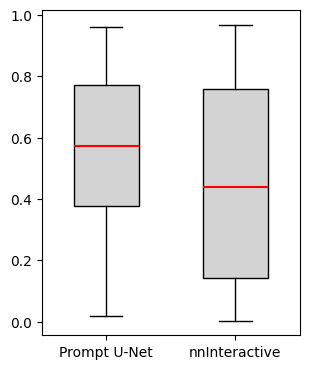

In [4]:
with open("results_3d_body_no_interactions_21_combined.pkl", "rb") as f:
    loaded_results = pickle.load(f)
show_avg_dice(loaded_results)
plot_dice_boxplots_from_results(loaded_results)

Not relevant:

Average Prompt U-Net Dice: 0.5387964910835307
Average nnInteractive Dice: 0.480909673931649
Average Prompt U-Net Window Dice: 0.8053125895870229
Average nnInteractive Window Dice: 0.731548277505984
Average Interactions: 1.0


/tmp/ipykernel_3107260/2103034352.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


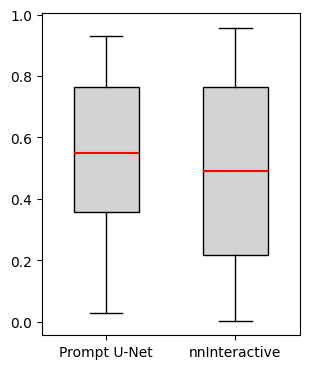

In [5]:
with open("results_3d_body_no_interactions_22_combined.pkl", "rb") as f:
    loaded_results = pickle.load(f)
show_avg_dice(loaded_results)
plot_dice_boxplots_from_results(loaded_results)